In [15]:
import pandas as pd
import numpy as np

# load dataset
data = pd.read_csv('water_data.csv')
data = data[['Date', 'Rainfall_Le_Croci', 'Temperature_Firenze', 'Hydrometry_Nave_di_Rosano']].copy()
data.columns = ['Date', 'Rainfall', 'Temperature', 'Flow']

data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
data = data.sort_values('Date').reset_index(drop=True)
data = data.ffill().bfill()

# basic lags & rolling
data['Rainfall_Lag1'] = data['Rainfall'].shift(1)
data['Rainfall_Lag2'] = data['Rainfall'].shift(2)
data['Flow_Lag1'] = data['Flow'].shift(1)
data['Rainfall_3D_Sum'] = data['Rainfall'].rolling(3).sum()
data['Rainfall_7D_Sum'] = data['Rainfall'].rolling(7).sum()

df = data.dropna().reset_index(drop=True)
print(df.shape)

(8211, 9)


In [26]:
# extra lag features
df['Flow_Lag1'] = df['Flow'].shift(1)
df['Flow_Lag2'] = df['Flow'].shift(2)
df['Rain_Lag1'] = df['Rainfall'].shift(1)

# rolling windows for soil moisture / memory
win_list = [3, 7, 15, 30]
for w in win_list:
    df[f'Rain_Sum_{w}d'] = df['Rainfall'].rolling(window=w).sum()
    df[f'Rain_Std_{w}d'] = df['Rainfall'].rolling(window=w).std()
    df[f'Flow_Mean_{w}d'] = df['Flow_Lag1'].rolling(window=w).mean()

# EWMA for recent rainfall weight
df['Rain_EWMA_7'] = df['Rainfall'].ewm(span=7, adjust=False).mean()

df = df.dropna().reset_index(drop=True)
print(f"Total variables: {df.shape[1]}")

Total variables: 24


In [20]:
X = df.drop(columns=['Date', 'Flow'])
y = df['Flow']

# 80-20 temporal split
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 6472 samples
Testing set: 1619 samples


In [25]:
import time
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'n_estimators': [200, 500],
    'learning_rate': [0.01, 0.05],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 1.0]
}

print("Starting Grid Search CV...")
t_start = time.time()

model = XGBRegressor(random_state=42)
grid_search = GridSearchCV(model, param_grid, cv=tscv, scoring='neg_mean_squared_error', verbose=1, n_jobs=-1)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

t_taken = (time.time() - t_start) / 60
print(f"\nOptimization complete in {t_taken:.1f} minutes.")
print(f"Best parameters: {grid_search.best_params_}")

Starting Grid Search CV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Optimization complete in 2.7 minutes.
Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


Test Set Evaluation -> RMSE: 0.27 m³/s | NSE: 0.81

Calculating SHAP values for interpretability...


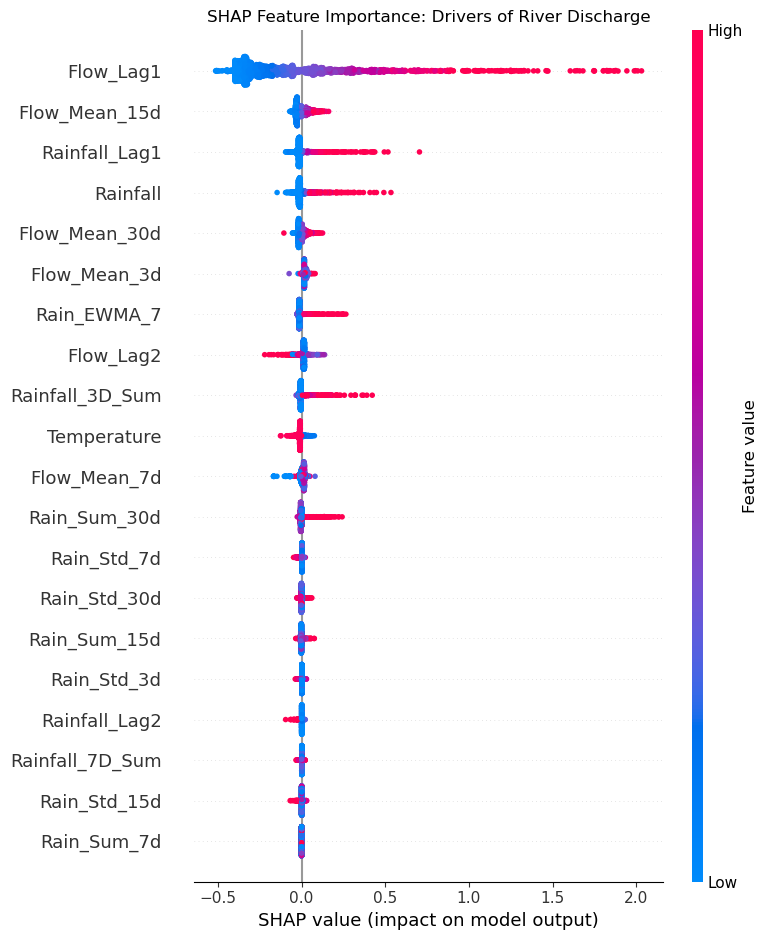


Model and baseline features saved for deployment.


In [23]:
import shap
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib

# Final Model Evaluation
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
numerator = np.sum((y_test.values - y_pred)**2)
denominator = np.sum((y_test.values - np.mean(y_test.values))**2)
nse = 1 - (numerator / denominator)

print(f"Test Set Evaluation -> RMSE: {rmse:.2f} m³/s | NSE: {nse:.2f}")

# SHAP Feature Importance Analysis
print("\nCalculating SHAP values for interpretability...")
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Importance: Drivers of River Discharge")
plt.tight_layout()
plt.show()

# Export artifacts for Streamlit deployment
joblib.dump(best_model, 'xgboost_river_model.pkl')
X_train.tail(1).to_csv('baseline_features.csv', index=False)
print("\nModel and baseline features saved for deployment.")